In [71]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [72]:
df=pd.read_csv('/content/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [74]:
df['total_bedrooms'].mean()

np.float64(537.8705525375618)

In [75]:
df=df.fillna(value=df['total_bedrooms'].mean())

In [76]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['ocean_proximity']=le.fit_transform(df['ocean_proximity'])

### Feature Engineering

To improve the model's performance, let's create some new features from the existing ones. These derived features can sometimes provide more meaningful information to the model than the raw features alone.

We will create:
-   **`rooms_per_household`**: The average number of rooms per household.
-   **`bedrooms_per_room`**: The ratio of total bedrooms to total rooms.
-   **`population_per_household`**: The average number of people per household.

In [77]:
X=df.drop('median_house_value', axis=1)
y=df['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [79]:
from tensorflow.keras.regularizers import l2

model=Sequential()
model.add(Dense(256, activation='relu', input_shape=[X_train.shape[1], ], kernel_regularizer=l2(0.001))),
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001))),
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001))),
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001))),
model.add(Dropout(0.2))
model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [80]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 256)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,825 (179.00 KB)

 Trainable params: 45,825 (179.00 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
es=EarlyStopping(monitor='val_loss', mode='min', patience=20, restore_best_weights=True)

In [82]:
history=model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=100,  callbacks=[es], batch_size=50)

Epoch 1/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 35193823232.0000 - mae: 149351.7812 - val_loss: 12237091840.0000 - val_mae: 86009.6719
Epoch 2/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 12174449664.0000 - mae: 86676.9688 - val_loss: 10576287744.0000 - val_mae: 80411.7188
Epoch 3/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10290928640.0000 - mae: 79617.6484 - val_loss: 8360731136.0000 - val_mae: 71258.2734
Epoch 4/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8103604224.0000 - mae: 69168.3828 - val_loss: 6367361536.0000 - val_mae: 59483.3359
Epoch 5/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7113696256.0000 - mae: 62672.5312 - val_loss: 6025292800.0000 - val_mae: 55861.0625
Epoch 6/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6761963520.0000 - mae: 60642.3555 - val_loss: 5848092672.0000 - val_mae: 55818.8477
Epoch 7/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6718856704.0000 - mae: 60266.2734 - val_loss: 5752461824.0000 -

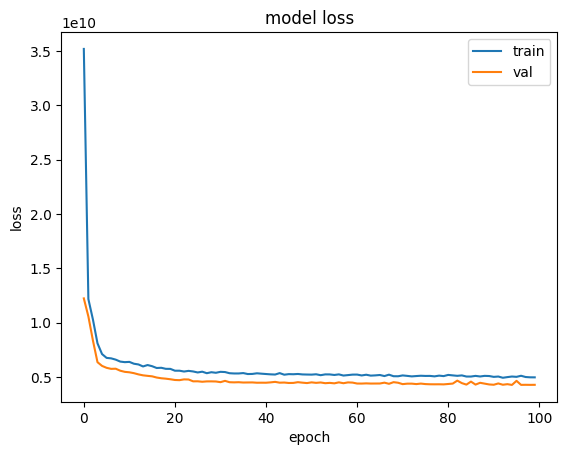

In [85]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'],)

In [86]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,mean_squared_log_error

y_pred = model.predict(X_test_scaled)
print("mae :", mean_absolute_error(y_test,y_pred))
print("mse :", mean_squared_error(y_test,y_pred))
print("mae :", mean_squared_log_error(y_test,y_pred))
print("score :", r2_score(y_test,y_pred))

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
mae : 45239.478656620944
mse : 4169909006.560127
mae : 0.09965924107436565
score : 0.68178568097436


In [87]:
def pred(longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity):
    features = np.array([longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity])
    features_scaled = scaler.fit_transform([features])
    results = model.predict(features_scaled).reshape(1,-1)
    return results[0]

In [88]:
longitude = -122.2300
latitude  = 37.8800
housing_median_age  = 41.0000
total_rooms        = 880.0000
total_bedrooms   =  129.0000
population     = 322.0000
households          =    126.0000
median_income       =      8.3252
ocean_proximity       =     3.0000

price = pred(longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


In [89]:
price

array([677492.8], dtype=float32)

In [90]:
model.save('model_ann.h5')
import pickle
pickle.dump(scaler, open('min_max_scaler.pkl', 'wb'))